# Multilayer Neural Network from Scratch

Imports 

In [1]:
import numpy
import pandas
from matplotlib import pyplot as plot
import seaborn as sns

Loading dataset..

In [2]:
trainData = pandas.read_csv('./train.csv')
XTrain = trainData.drop("label", axis = 1)
YTrain = trainData['label']
digits = XTrain

[]

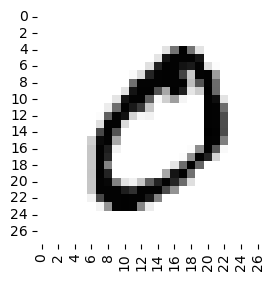

In [3]:
number = digits.iloc[1].values.reshape(28, 28)
plot.figure(figsize = (3, 3))

sns.heatmap(number, cmap = 'Greys', cbar = False)
plot.plot()

Scaling Data

In [4]:
XTrain = XTrain/255
digits = XTrain

In [5]:
digits.shape[0]

60000

In [6]:
# ======================= Activation Functions==============================
def ReLU(X):
    return numpy.maximum(0, X)

def softMax(X):
    max_X = numpy.max(X, axis=0, keepdims=True)
    shifted_X = X - max_X
    exp_X = numpy.exp(shifted_X)
    return exp_X / numpy.sum(exp_X, axis=0, keepdims=True)

def ReLUDer(X):
    return X>0

One Hot Encoding Y labels

In [7]:
encodedDf = pandas.get_dummies(YTrain, drop_first=False).astype(int)
encodedDf

,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,1,0
59996,0,0,0,1,0,0,0,0,0,0
59997,0,0,0,0,0,1,0,0,0,0
59998,0,0,0,0,0,0,1,0,0,0


In [8]:
encodedDf = numpy.array(encodedDf)

In [9]:
# ================ Forward Propagation ===================================
def forwardPropagation(W1, W2, b1, b2, digits):
    X = numpy.array(digits)
    Z1 = W1.dot(numpy.transpose(X)) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softMax(Z2)

    return A1, A2, Z1, Z2
# =======================================================================

# ================= Backward propagation =================================
def backPropagation(A1, A2, Z1, Z2, W1, W2, digits, Y):
    X = numpy.array(digits)
    m = digits.shape[0]
    dZ2 = A2 - Y
    dW2 = (1 / m) * numpy.dot(dZ2, A1.T)
    db2 = (1 / m) * numpy.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = numpy.dot(W2.T, dZ2) * ReLUDer(Z1)
    dW1 = (1 / m) * numpy.dot(dZ1, X)
    db1 = (1 / m) * numpy.sum(dZ1, axis=1, keepdims=True)

    return dW1, dW2, db1, db2
# ========================================================================


In [10]:
def get_predictions(A2):
    return numpy.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return (numpy.sum(predictions == Y) / Y.size)*100

def gradientDescent(Y, alpha, iterations):
    print("Training started....")
    # ============= Initializing Random weights and biases ===================
    W1 = numpy.random.randn(10, 784) * 0.01
    W2 = numpy.random.randn(10, 10) * 0.01
    b1 = numpy.zeros((10, 1))
    b2 = numpy.zeros((10, 1))
    # ========================================================================

    for i in range(iterations):
        A1, A2, Z1, Z2 = forwardPropagation(W1, W2, b1, b2, digits)
        dW1, dW2, db1, db2 = backPropagation(A1, A2, Z1, Z2, W1, W2, digits, encodedDf.T)
        
        # ============================= Updating parameters =========================
        W1 = W1 - (alpha * dW1)
        W2 = W2 - (alpha * dW2)
        b1 = b1 - (alpha * db1)
        b2 = b2 - (alpha * db2)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print('accuracy: ', get_accuracy(predictions, Y))
    
    print("Training - 100%")

    return W1, W2, b1, b2

In [11]:
W1, W2, b1, b2 = gradientDescent(YTrain, 0.10, 500)

Training started....
Iteration:  0
[9 4 9 ... 9 4 9] 0        5
1        0
2        4
3        1
4        9
        ..
59995    8
59996    3
59997    5
59998    6
59999    8
Name: label, Length: 60000, dtype: int64
accuracy:  8.321666666666665
Iteration:  10
[1 1 1 ... 1 1 1] 0        5
1        0
2        4
3        1
4        9
        ..
59995    8
59996    3
59997    5
59998    6
59999    8
Name: label, Length: 60000, dtype: int64
accuracy:  11.298333333333334
Iteration:  20
[1 1 1 ... 1 1 1] 0        5
1        0
2        4
3        1
4        9
        ..
59995    8
59996    3
59997    5
59998    6
59999    8
Name: label, Length: 60000, dtype: int64
accuracy:  13.123333333333335
Iteration:  30
[1 0 1 ... 1 1 1] 0        5
1        0
2        4
3        1
4        9
        ..
59995    8
59996    3
59997    5
59998    6
59999    8
Name: label, Length: 60000, dtype: int64
accuracy:  20.145
Iteration:  40
[0 0 0 ... 0 0 0] 0        5
1        0
2        4
3        1
4        9
     

Testing Accuracy with test dataset

In [12]:
testDf = pandas.read_csv("./test.csv")
testDf

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
testDf.shape

(10000, 785)

In [14]:
YTest = testDf['label']
XTest = testDf.drop(columns=['label'], axis=1)
XTest = XTest/255

In [15]:
_, A2, _, _ = forwardPropagation(W1, W2, b1, b2, XTest)
predictions = get_predictions(A2)
testAccuracy = (numpy.sum(predictions==YTest)/YTest.size) * 100

In [16]:
print(f"Testing Data accuracy : {testAccuracy}")

Testing Data accuracy : 89.25


To Visualize the confusion matrix ( Using SkLearn )

In [17]:
from sklearn import metrics

In [20]:
confusionMatrix = metrics.confusion_matrix(YTest, predictions)
ConfusionMatrixDisplay = metrics.ConfusionMatrixDisplay(confusion_matrix = confusionMatrix)

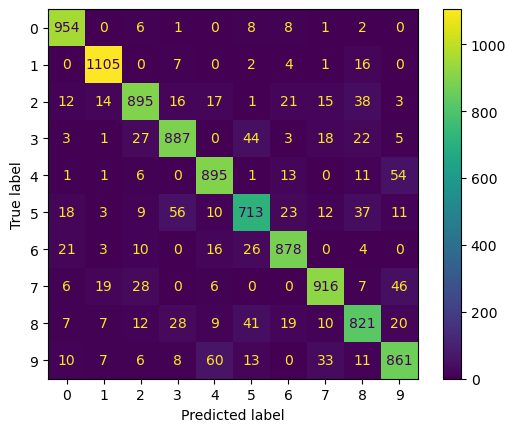

In [21]:
ConfusionMatrixDisplay.plot()
plot.show()